# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df2 = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])
print('Loaded from:', csv_path)
df2.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [ ]:
# TODO
print(f"Số dòng: ", df2.shape[0], "| Số cột: ", df2.shape[1])
print()
print("Tên cột: ", df2.columns.tolist())
print(df2.info())

Số dòng:  541909 | Số cột:  8

Tên cột:  ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB
None


## A.2. Missing values & Duplicate data

In [ ]:
# TODO
print("Số cột thiếu dữ liệu:")
missing = df2.isnull().sum()
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu")
print("Số lượng dữ liệu bị trùng: ", df2.duplicated().sum())

print("Duplicate theo khóa InvoiceNo+StockCode:", df2.duplicated(subset=['InvoiceNo','StockCode']).sum())
dup = df2[df2.duplicated(subset=['InvoiceNo', 'StockCode'],keep=False)]
display(dup.sort_values(['InvoiceNo', 'StockCode']).head(10))
dup2= df2[df2.duplicated(keep=False)]
display((dup2.sort_values(['InvoiceNo', 'StockCode'])).head(10))

print("Trong dữ liệu có 5268 dòng bị trùng hoàn toàn -> drop dòng trùng")
df2 = df2.drop_duplicates()
print("Số lượng dữ liệu trùng sau khi xóa: ", df2.duplicated().sum())

print("Nhận xét: Có thể thấy rằng trong bảng có các dòng trùng khóa nhưng k phải lỗi mà là trong 1 hóa đơn có nhiều sản phẩm có số lượng khác nhau")


Số cột thiếu dữ liệu:
Description      1454
CustomerID     135080
dtype: int64
Số lượng dữ liệu bị trùng:  5268
Duplicate theo khóa InvoiceNo+StockCode: 10684


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


Trong dữ liệu có 5268 dòng bị trùng hoàn toàn -> drop dòng trùng
Số lượng dữ liệu trùng sau khi xóa:  0
Nhận xét: Có thể thấy rằng trong bảng có các dòng trùng khóa nhưng k phải lỗi mà là trong 1 hóa đơn có nhiều sản phẩm có số lượng khác nhau


## A.3. Invalid values

In [ ]:
# TODO
print("Quantity<0", (df2['Quantity']<0).sum())
display(df2[df2['Quantity']<=0].head(5))
print("UnitPrice<0", (df2['UnitPrice']<0).sum())
display(df2[df2['UnitPrice']<=0].head())
print(df2['Country'].value_counts())
print("Ngày nhỏ nhất:", df2['InvoiceDate'].min())
print("Ngày lớn nhất:", df2['InvoiceDate'].max())


Quantity<0 10587


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


UnitPrice<0 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [ ]:
# TODO
df2 = df2[(df2['Quantity']>0) & (df2['UnitPrice']>0)]
(df2['Quantity']<0).sum()
(df2['UnitPrice']<0).sum()
df2['Sales'] = df2['Quantity']*df2['UnitPrice']
df2.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    mean_, median_, mode_ = df2[col].mean(), df2[col].median(), df2[col].mode()[0]
    print(f"---{col}---")
    print(f"Mean= {mean_}, Median= {median_}, Mode= {mode_}")

---UnitPrice---
Mean= 3.9225725673394582, Median= 2.08, Mode= 1.25
---Quantity---
Mean= 10.616600429052085, Median= 4.0, Mode= 1
---Sales---
Mean= 20.275398862211794, Median= 9.92, Mode= 15.0


## Group 2 — Dispersion

In [ ]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df2[col]
    range_ = s.max() - s.min()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3-q1
    std_ = s.std()
    cv = std_/s.mean()*100
    print(f"---{col}---")
    print(f"range= {range_}, iqr= {iqr}, std= {std_}, cv= {cv}")

---UnitPrice---
range= 13541.329, iqr= 2.88, std= 36.09302753192425, cv= 920.1366427850403
---Quantity---
range= 80994, iqr= 10.0, std= 156.2800307234939, cv= 1472.0345911845486
---Sales---
range= 168469.59900000002, iqr= 13.800000000000002, std= 271.69356629922254, cv= 1340.0158889381482


## Group 3 — Location and Shape

---UnitPrice---
Skew= 205.084581903764, Kurtosis= 61873.12945450053
---Quantity---
Skew= 469.5404429060045, Kurtosis= 234226.47293933306
---Sales---
Skew= 504.23112111629985, Kurtosis= 294738.33525783883


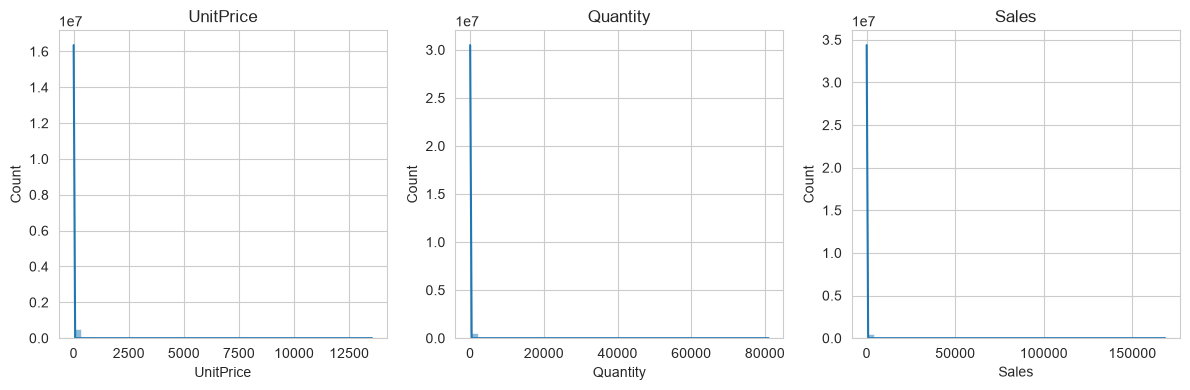

Nhận xét: cả ba đồ thị đề có skew dương rất lớn -> đồ thì lệch phải rất mạnh. kurtosis cũng rất cao cho thấy phần đuôi nặng và có thể có các giá trị cực đoan.


In [ ]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df2[col]
    skew_, kurtosis_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"Skew= {skew_}, Kurtosis= {kurtosis_}")


fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.histplot(df2['UnitPrice'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('UnitPrice')
sns.histplot(df2['Quantity'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('Quantity')
sns.histplot(df2['Sales'], bins=40, kde=True, ax=axes[2]); axes[2].set_title('Sales')
plt.tight_layout(); plt.show()

print("Nhận xét: cả ba đồ thị đề có skew dương rất lớn -> đồ thì lệch phải rất mạnh. kurtosis cũng rất cao cho thấy phần đuôi nặng và có thể có các giá trị cực đoan.")


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [ ]:
# TODO
tc = df2.groupby('Country')['Sales'].sum().sort_values(ascending=False)

print(f"Country có doanh thu cao nhất: {tc.idxmax()}, Doanh thu= {tc.max()}")
print(tc)

ss = df2['Sales'].sum()
perc = tc.max()/ss*100
print(f"Chiếm {perc.round(2)} % tổng doanh thu")


Country có doanh thu cao nhất: United Kingdom, Doanh thu= 9001744.094
Country
United Kingdom          9001744.094
Netherlands              285446.340
EIRE                     283140.520
Germany                  228678.400
France                   209625.370
Australia                138453.810
Spain                     61558.560
Switzerland               57067.600
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33683.050
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Hong Kong                 15483.000
Cyprus                    13502.850
Austria                   10198.680
Israel                     8129.410
Poland                     7334.650
Greece                     4760.520
Unspecified                4740.940
Iceland               

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [ ]:
# TODO
tp = df2.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(f"Sản phẩm bán chạy nhất theo doanh thu là {tp.idxmax()} với doanh thu= {tp.max()}")

Sản phẩm bán chạy nhất theo doanh thu là DOTCOM POSTAGE với doanh thu= 206248.77


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [ ]:
# TODO
df2['Month'] = df2['InvoiceDate'].dt.month

print(df2.groupby('Month')['Sales'].sum())
print("Nhận xét: doanh số có tính mùa vụ theo tháng, doanh thu tăng mạnh ở tháng 9 đến tháng 12. Tháng 11 có doanh thu cao nhất. Từ tháng 1 đến tháng 8 doanh thu thấp hơn đáng kể ")

Month
1      689811.610
2      522545.560
3      716215.260
4      536968.491
5      769296.610
6      760547.010
7      718076.121
8      757841.380
9     1056435.192
10    1151263.730
11    1503866.780
12    1459243.060
Name: Sales, dtype: float64
Nhận xét: doanh số có tính mùa vụ theo tháng, doanh thu tăng mạnh ở tháng 9 đến tháng 12. Tháng 11 có doanh thu cao nhất. Từ tháng 1 đến tháng 8 doanh thu thấp hơn đáng kể 


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [ ]:
# TODO
print(df2.groupby('Country')['Sales'].mean().sort_values(ascending=False))
print("Nhận xét: giá trị đơn hàng trung bình có sự khác nhau giữa các quốc gia. Một số quốc gia như Australia, Netherlands, Japan, Singapore, Sweden có giá trị dơn hàng trung bình cao hơn nhiều so với trung bình đơn hàng giữa các quốc gia")

Country
Netherlands             121.003111
Australia               117.234386
Japan                   116.561900
Singapore                95.852658
Sweden                   85.261844
Hong Kong                55.296429
Denmark                  49.882474
Lithuania                47.458857
Bahrain                  41.896667
Lebanon                  37.641778
EIRE                     35.936098
Brazil                   35.737500
Norway                   33.767918
Czech Republic           33.069600
Finland                  32.913985
Greece                   32.831172
Switzerland              29.145863
United Arab Emirates     27.974706
Israel                   27.840445
Channel Islands          27.363507
Austria                  25.624824
Germany                  25.338327
France                   24.979191
Spain                    24.832013
Malta                    24.335625
Canada                   24.280662
Iceland                  23.681319
Italy                    23.064960
Portugal    

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [59]:
# TODO
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df2 = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])
print('Loaded from:', csv_path)

print("--------------------")
df2['ReturnQuantity'] = df2['Quantity']<0
pc = df2.groupby('Country')['ReturnQuantity'].mean()*100

print(pc.sort_values(ascending=False))
print("Nhận xét: tỉ lệ hủy/trả hàng ở USE cao hơn nhiều so với tỉ lệ trả hàng ở các khu vực khác. Trong khi đó có nhiều quốc gia có tỉ lệ hủy/trả hàng là 0%")

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv
--------------------
Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.877681
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.770932
EIRE                     3.684724
Poland                   3.225806
Singapore                3.056769
Sweden                   2.380952
Denmark                  2.313625
Spain                    1.894986
United Kingdom           1.855178
Belgium                  1.836636
Switzerland              1.748252
France                   1.741264
European Community       1.639344
Finland                  1.438849
Hong Kong                1.388889
Channel Islands          1.319261
Norway                   1.289134
Cyprus          

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu có nhiều dòng bị trùng và thiếu dữ liệu

UnitPrice có giá trị lớn và nhỏ nhất cách nhau 13541 đơn vị, giá trung bình là 3.9, dữ liệu biến động rất lớn 919%. Skew = 206 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

Quantity có giá trị lớn và nhỏ nhất cách nhau 80994 đơn vị, số lượng trung bình là 3.0, dữ liệu biến động rất lớn 1475%. Skew = 471 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

Quantity có giá trị lớn và nhỏ nhất cách nhau 80994 đơn vị, số lượng trung bình là 3.0, dữ liệu biến động rất lớn 270%. Skew = 506 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

United Kingdom có doanh thu cao nhất với 9,025,222.084, chiếm 84.61% tổng doanh thu. Doanh thu của United Kingdom vượt xa các quốc gia còn lại, trong đó Netherlands đứng thứ hai nhưng chỉ đạt 285,446.340. Điều này cho thấy doanh thu tập trung rất lớn United Kingdom.

Doanh số có tính mùa vụ theo thàng, từ tháng 9 đến tháng 12 doan thu tăng mạnh nhưng từ tháng 1 đến tháng 8 doanh thu thấp hơn đáng kể.

Sản phẩm có doanh thu cao nhất là DOTCOM POSTAGE với doanh thu 206,248.77, cho thấy đây là sản đóng góp doanh thu lớn nhất.

Tỉ lệ hủy/trả hàng ở USE cao hơn nhiều so với tỉ lệ trả hàng ở các khu vực khác. Trong khi đó có nhiều quốc gia có tỉ lệ hủy/trả hàng là 0%
